In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🩺 Diagnostic Assisté par IA : Prédiction du Cancer du Sein
**Auteur:** [Hamouche / Cherarak]  
**Date:** Avril 2026

[![GitHub](https://img.shields.io/badge/GitHub-Consulter_le_dépôt-181717?logo=github)](https://github.com/Tonikr122/prediction-cancer-ia)

## 📌 1. Contexte du Projet et Objectifs
Le diagnostic précoce du cancer du sein améliore considérablement les chances de survie des patients. Ce projet vise à développer un modèle de Machine Learning capable de classifier les tumeurs mammaires en deux catégories : **Bénignes** ou **Malignes**, à partir de caractéristiques d'images cellulaires numérisées (Dataset Breast Cancer Wisconsin).

**Objectifs analytiques :**
1. Explorer et préparer les données médicales.
2. Entraîner un modèle robuste (Forêt Aléatoire).
3. Évaluer les performances avec une attention particulière sur le **Rappel (Sensibilité)** afin de minimiser les faux négatifs (diagnostics manqués).
4. Identifier les biomarqueurs (caractéristiques) les plus déterminants pour le diagnostic.



In [2]:
# Importation de pandas pour la manipulation des données en tableaux (DataFrames)
import pandas as pd

# Importation de numpy pour les opérations mathématiques avancées
import numpy as np

# Importation de pyplot depuis matplotlib pour créer des graphiques de base
import matplotlib.pyplot as plt

# Importation de seaborn pour créer des graphiques statistiques plus esthétiques
import seaborn as sns

# Importation du jeu de données officiel sur le cancer du sein depuis scikit-learn
from sklearn.datasets import load_breast_cancer

# Importation de la fonction pour diviser les données en entraînement et test
from sklearn.model_selection import train_test_split

# Importation du StandardScaler pour normaliser les données (mettre à la même échelle)
from sklearn.preprocessing import StandardScaler

# Importation de l'algorithme Random Forest (Forêt Aléatoire) pour la classification
from sklearn.ensemble import RandomForestClassifier

# Importation des métriques d'évaluation pour juger la performance du modèle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importation du module warnings pour gérer les messages d'avertissement
import warnings

# Configuration de warnings pour ignorer les avertissements non critiques lors de l'exécution
warnings.filterwarnings('ignore')


## 2. Acquisition et Analyse Exploratoire des Données (EDA)
Avant de modéliser, il est essentiel de comprendre la structure de nos données, de vérifier s'il manque des informations et d'observer la distribution des diagnostics (notre variable cible).


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostic
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Valeurs manquantes par colonne :
 0


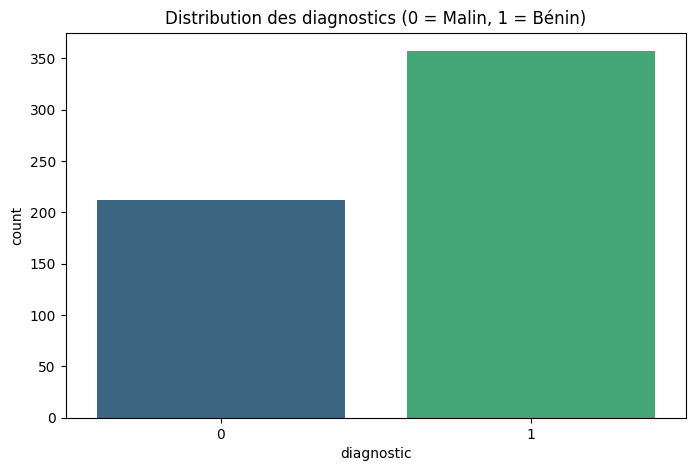

In [3]:
# Chargement du jeu de données dans une variable nommée 'data'
data = load_breast_cancer()

# Création d'un DataFrame pandas avec les variables explicatives (features)
df = pd.DataFrame(data.data, columns=data.feature_names)

# Ajout de la colonne cible (diagnostic : 0 pour malin, 1 pour bénin) au DataFrame
df['diagnostic'] = data.target

# Affichage des 5 premières lignes du DataFrame pour inspection visuelle
display(df.head())

# Vérification rapide des valeurs manquantes dans tout le DataFrame (somme par colonne)
print("Valeurs manquantes par colonne :\n", df.isnull().sum().max())

# Définition de la taille de la figure pour le graphique à venir
plt.figure(figsize=(8, 5))

# Création d'un graphique à barres pour compter le nombre de cas bénins et malins
sns.countplot(x='diagnostic', data=df, palette='viridis')

# Ajout d'un titre clair et descriptif au graphique
plt.title("Distribution des diagnostics (0 = Malin, 1 = Bénin)")

# Affichage du graphique à l'écran
plt.show()


## 3. Ingénierie et Préparation des Données
Les algorithmes d'IA sont sensibles à l'échelle des données. Par exemple, une caractéristique mesurée en millimètres et une autre en micromètres n'auront pas le même poids mathématique. Nous devons donc **standardiser** nos données après les avoir séparées pour éviter toute fuite d'information (data leakage).


In [4]:
# Isolation des variables explicatives en supprimant la colonne cible
X = df.drop('diagnostic', axis=1)

# Isolation de la variable cible (ce que l'on veut prédire)
y = df['diagnostic']

# Division des données : 80% pour l'entraînement (train) et 20% pour le test (test)
# L'argument stratify=y garantit que la proportion de tumeurs malignes/bénignes reste la même dans les deux sous-ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialisation de l'outil de standardisation (moyenne=0, écart-type=1)
scaler = StandardScaler()

# Calcul des paramètres de standardisation sur les données d'entraînement ET application de la transformation
X_train_scaled = scaler.fit_transform(X_train)

# Application de la transformation sur les données de test (sans recalculer les paramètres)
X_test_scaled = scaler.transform(X_test)

# Affichage des dimensions de l'ensemble d'entraînement pour vérification
print(f"Taille du jeu d'entraînement : {X_train_scaled.shape}")

# Affichage des dimensions de l'ensemble de test pour vérification
print(f"Taille du jeu de test : {X_test_scaled.shape}")


Taille du jeu d'entraînement : (455, 30)
Taille du jeu de test : (114, 30)


## 4. Modélisation : Entraînement de l'Intelligence Artificielle
Nous choisissons le **Random Forest** (Forêt Aléatoire). C'est un modèle d'ensemble qui crée de multiples arbres de décision et les fait voter. Il est très performant, résiste bien au surapprentissage (overfitting) et permet d'interpréter l'importance de chaque caractéristique médicale.


In [5]:
# Instanciation du modèle avec 100 arbres de décision (n_estimators=100) et une graine aléatoire fixe (random_state=42) pour la reproductibilité
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Entraînement du modèle sur les données d'entraînement standardisées
rf_model.fit(X_train_scaled, y_train)

# Utilisation du modèle entraîné pour prédire les diagnostics sur l'ensemble de test
y_pred = rf_model.predict(X_test_scaled)


## 5. Évaluation des Performances
En médecine, une "Accuracy" (précision globale) élevée ne suffit pas. Il faut regarder la **Matrice de Confusion** et le **Rapport de Classification**.
* **Faux Négatif (FN) :** Le modèle dit que le patient est sain alors qu'il a un cancer. C'est l'erreur la plus dangereuse à minimiser.


Précision Globale (Accuracy) : 95.61%



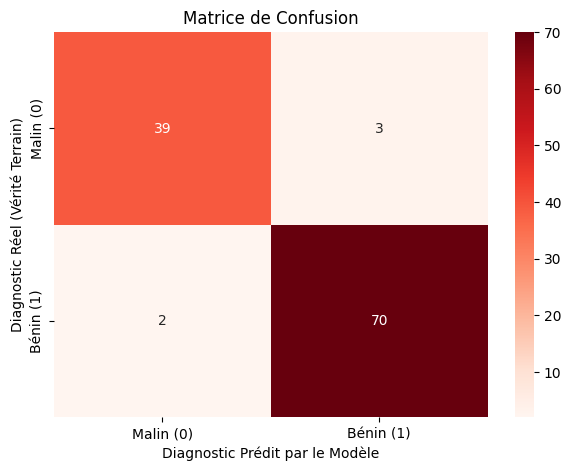


--- Rapport de Classification Détaillé ---
              precision    recall  f1-score   support

   Malin (0)       0.95      0.93      0.94        42
   Bénin (1)       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [6]:
# Calcul du score de précision globale (nombre de bonnes prédictions / nombre total)
accuracy = accuracy_score(y_test, y_pred)

# Affichage de la précision globale formatée en pourcentage avec 2 décimales
print(f"Précision Globale (Accuracy) : {accuracy * 100:.2f}%\n")

# Création de la figure pour la matrice de confusion
plt.figure(figsize=(7, 5))

# Calcul de la matrice de confusion en comparant les vraies étiquettes aux prédictions
cm = confusion_matrix(y_test, y_pred)

# Génération d'une carte de chaleur (heatmap) pour visualiser la matrice de confusion de façon claire
# annot=True affiche les chiffres, fmt='d' les met en format entier, cmap définit les couleurs
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Malin (0)', 'Bénin (1)'], yticklabels=['Malin (0)', 'Bénin (1)'])

# Ajout de l'étiquette pour l'axe des ordonnées (Y)
plt.ylabel('Diagnostic Réel (Vérité Terrain)')

# Ajout de l'étiquette pour l'axe des abscisses (X)
plt.xlabel('Diagnostic Prédit par le Modèle')

# Ajout du titre du graphique
plt.title('Matrice de Confusion')

# Affichage du graphique
plt.show()

# Affichage du texte introduisant le rapport de classification
print("\n--- Rapport de Classification Détaillé ---")

# Génération et affichage du rapport contenant Précision, Rappel et F1-Score pour chaque classe
print(classification_report(y_test, y_pred, target_names=['Malin (0)', 'Bénin (1)']))


## 6. Interprétabilité : Importance des Caractéristiques Médicales
Pour qu'une IA soit acceptée par le corps médical, elle doit être explicable ("Explainable AI"). Regardons quelles mesures cellulaires ont le plus influencé les décisions de notre modèle.


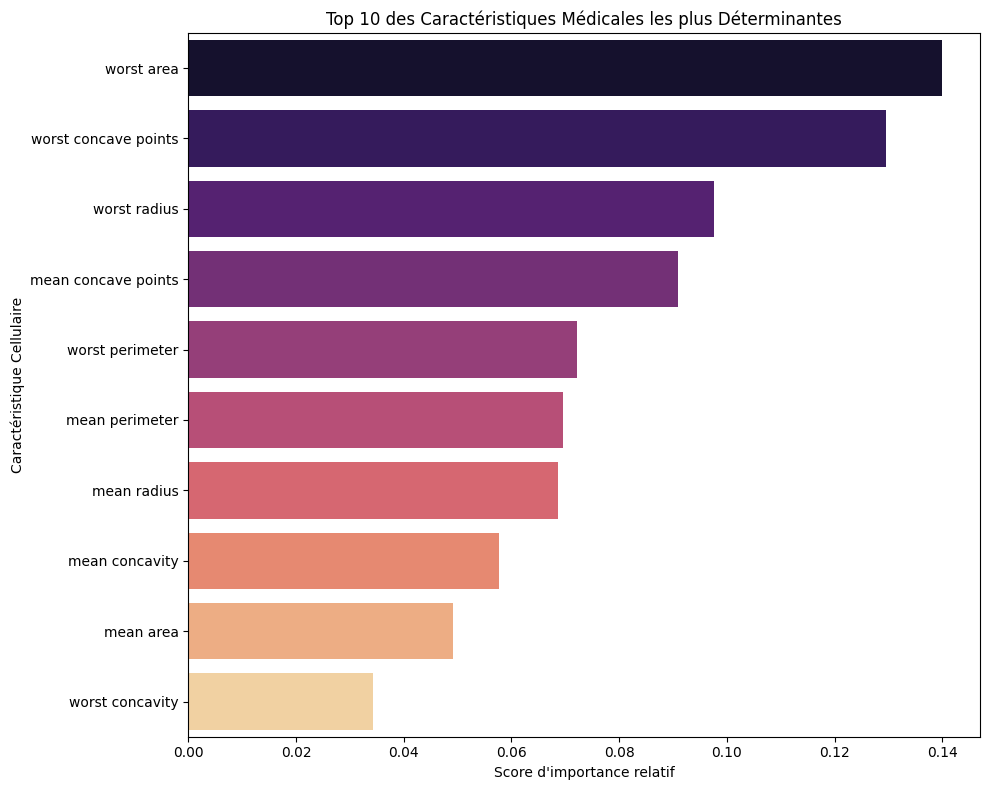

In [7]:
# Extraction des scores d'importance des caractéristiques depuis le modèle entraîné
importances = rf_model.feature_importances_

# Création d'un DataFrame associant chaque nom de caractéristique à son score d'importance
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Tri du DataFrame par ordre décroissant d'importance pour avoir les plus importantes en haut
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Création de la figure pour le graphique à barres horizontales
plt.figure(figsize=(10, 8))

# Création du graphique à barres montrant l'importance de chaque variable
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')

# Ajout d'un titre au graphique
plt.title('Top 10 des Caractéristiques Médicales les plus Déterminantes')

# Ajout d'une étiquette pour l'axe X
plt.xlabel('Score d\'importance relatif')

# Ajout d'une étiquette pour l'axe Y
plt.ylabel('Caractéristique Cellulaire')

# Ajustement de la mise en page pour éviter que les noms longs ne soient coupés
plt.tight_layout()

# Affichage du graphique
plt.show()
